# Potato Disease Classification , in my  data set  there  are  three    classification  probelm  which are Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy  

Dataset credits: https://www.kaggle.com/arjuntejaswi/plant-village

### Import all the Dependencies

In [1]:
import numpy as np
import  seaborn  as  sns 
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report
import  warnings
warnings.filterwarnings("ignore")

### Set all the Constants

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 128
CHANNELS=3

### Import data into tensorflow dataset object

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\potato-disease\PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 128, 128, 3)
[1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 1 2 0 0]


As you can see above, each element in the dataset is a tuple. First element is a batch of 32 elements of images. Second element is a batch of 32 elements of class labels 

### Visualize some of the images from our dataset

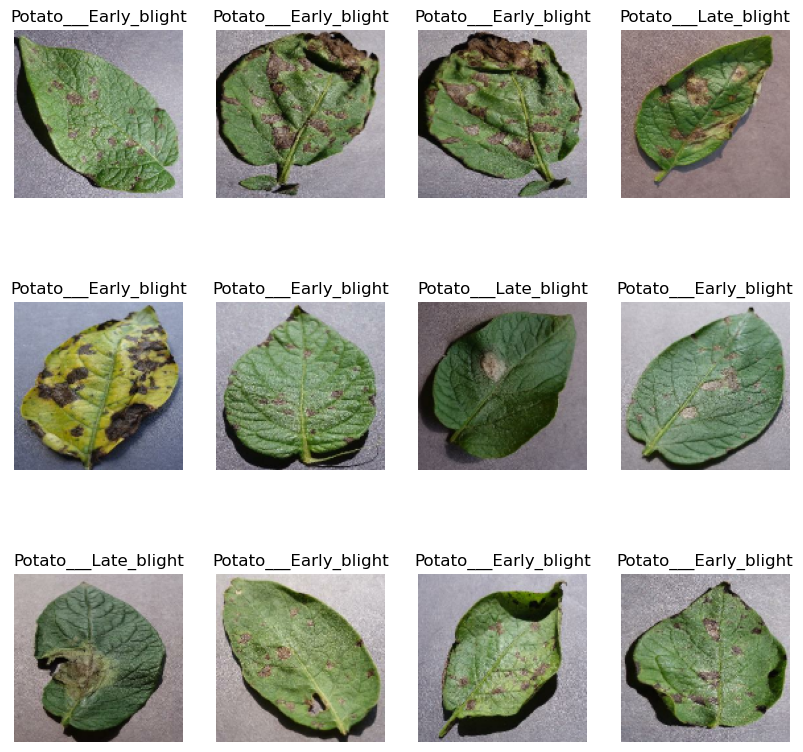

In [6]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

### Function to Split Dataset

Dataset should be bifurcated into 3 subsets, namely:
1. Training: Dataset to be used while training
2. Validation: Dataset to be tested against while training
3. Test: Dataset to be tested against after we trained a model

In [7]:
len(dataset)

68

In [8]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [9]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [10]:
len(train_ds)

54

In [11]:
len(val_ds)

6

In [12]:
len(test_ds)

8

## Building the Model

### Creating a Layer for Resizing and Normalization
You might be thinking why do we need to resize (128,128) image to again (128,128). You are right we don't need to but this will be useful when we are done with the training and start using the model for predictions. At that time somone can supply an image that is not (128,128) and this layer will resize it

In [13]:
def normalize(image, label):
    return image / 255.0, label

train_ds = train_ds.map(normalize)
val_ds = val_ds.map(normalize)
test_ds = test_ds.map(normalize)

In [14]:
for images, labels in train_ds.take(1):
    print("Min pixel value:", images.numpy().min())
    print("Max pixel value:", images.numpy().max())

Min pixel value: 0.0
Max pixel value: 0.9519608


### Cache, Shuffle, and Prefetch the Dataset

In [15]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

### Data Augmentation
Data Augmentation is needed when we have less data, this boosts the accuracy of our model by augmenting the data.

In [16]:
data_augmentation = tf.keras.Sequential( [
    layers.RandomFlip("horizontal_and_vertical") , 
    layers.RandomRotation(0.2),
    layers.RandomZoom (0.2) ])

#### Applying Data Augmentation to Train Dataset

### Model Architecture
We use a CNN coupled with a Softmax activation in the output layer. We also add the initial layers for resizing, normalization and Data Augmentation.

In [17]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model_CNN= models.Sequential([

    # Only resizing (no rescaling)
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),

    # Data Augmentation
    data_augmentation,

    # CNN Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),

    # CNN Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # CNN Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(128, activation='relu'),
    layers.Dense(n_classes, activation='softmax')])

In [18]:
model_CNN.compile( optimizer='adam',  loss='sparse_categorical_crossentropy',  metrics=['accuracy'])

In [21]:
history_CNN= model_CNN.fit(train_ds,  validation_data=val_ds,   epochs=10)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 51s 240ms/step - accuracy: 0.6432 - loss: 0.8103 - val_accuracy: 0.7917 - val_loss: 0.5533
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.8169 - loss: 0.4453 - val_accuracy: 0.8594 - val_loss: 0.3527
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.8421 - loss: 0.3873 - val_accuracy: 0.8385 - val_loss: 0.3843
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step - accuracy: 0.8803 - loss: 0.2821 - val_accuracy: 0.9167 - val_loss: 0.2418
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step - accuracy: 0.9243 - loss: 0.2149 - val_accuracy: 0.9479 - val_loss: 0.1001
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 335ms/step - accuracy: 0.9266 - loss: 0.1962 - val_accuracy: 0.9531 - val_loss: 0.1080
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 348ms/step - accuracy: 0.9531 - loss: 0.1330 - val_accuracy: 0.9062 - val_loss: 0.2224
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 338ms/step - accuracy: 0.9460 - loss: 0.1445 - val_accura

In [22]:
history_CNN.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [23]:
history_CNN.params

{'verbose': 'auto', 'epochs': 10, 'steps': 54}

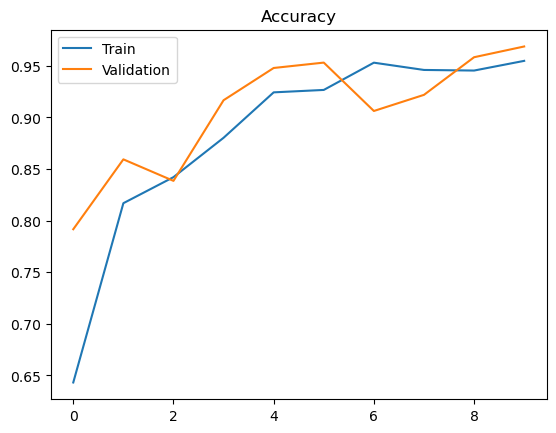

In [24]:
plt.plot(history_CNN.history['accuracy'])
plt.plot(history_CNN.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy")
plt.show()

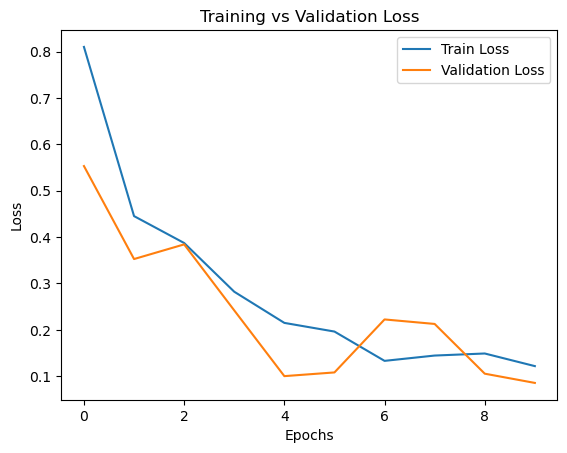

In [25]:
# Loss graph
plt.plot(history_CNN.history['loss'], label='Train Loss')
plt.plot(history_CNN.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# As  you  can  see  in  our  above  output  my  model  is  getting  overfitiing  after  6  epochs  so  now  i am  going  to  apply  Checkpoint and  erly  stopping   for  selecting  better  model  epochs  and  stoping  from  overfitiing  

In [26]:

checkpoint = ModelCheckpoint(
    "best_model.keras",   # better than .h5
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

history_earlystop = model_CNN.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint, early_stop] )

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 363ms/step - accuracy: 0.9442 - loss: 0.1639 - val_accuracy: 0.8177 - val_loss: 0.6048
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 352ms/step - accuracy: 0.9507 - loss: 0.1253 - val_accuracy: 0.9688 - val_loss: 0.1037
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 360ms/step - accuracy: 0.9577 - loss: 0.1137 - val_accuracy: 0.9740 - val_loss: 0.0862
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 363ms/step - accuracy: 0.9525 - loss: 0.1268 - val_accuracy: 0.8646 - val_loss: 0.4039
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 369ms/step - accuracy: 0.9577 - loss: 0.1108 - val_accuracy: 0.9427 - val_loss: 0.1740
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 358ms/step - accuracy: 0.9601 - loss: 0.1001 - val_accuracy: 0.9583 - val_loss: 0.1043


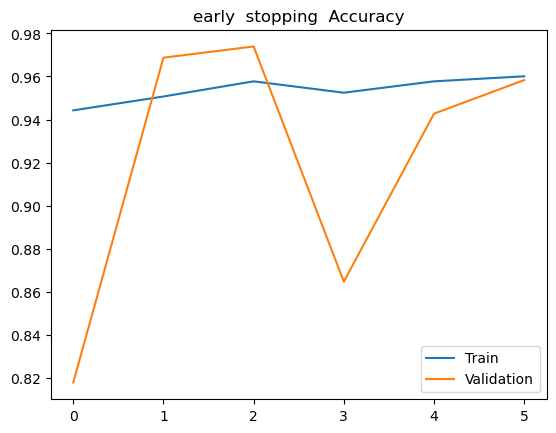

In [31]:
plt.plot(history_earlystop.history['accuracy'])
plt.plot(history_earlystop.history['val_accuracy'])
plt.legend(['Train', 'Validation'  ])
plt.title("early  stopping  Accuracy")
plt.show()

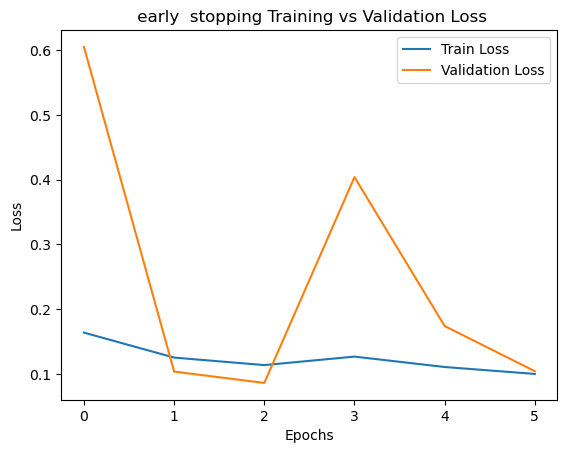

In [30]:
# Loss graph
plt.plot(history_earlystop.history['loss'], label='Train Loss')
plt.plot(history_earlystop.history['val_loss'], label='Validation Loss')

plt.title(' early  stopping Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [32]:
model_CNN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resizing (Resizing)                  │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,915,083 (37.82 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,610,056 (25.22 MB)

In [33]:
model_CNN.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.9648 - loss: 0.0951 


[0.09506852179765701, 0.96484375]

In [59]:
from tensorflow.keras.models import load_model

best_model = load_model("best_model.keras")

best_model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 349ms/step - accuracy: 0.9648 - loss: 0.0951


[0.09506852179765701, 0.96484375]

In [60]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_CNN.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm=confusion_matrix(y_true, y_pred)
print(cm)
print(classification_report(y_true, y_pred))

[[124   2   0]
 [  5 110   2]
 [  0   0  13]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       126
           1       0.98      0.94      0.96       117
           2       0.87      1.00      0.93        13

    accuracy                           0.96       256
   macro avg       0.94      0.97      0.95       256
weighted avg       0.97      0.96      0.96       256



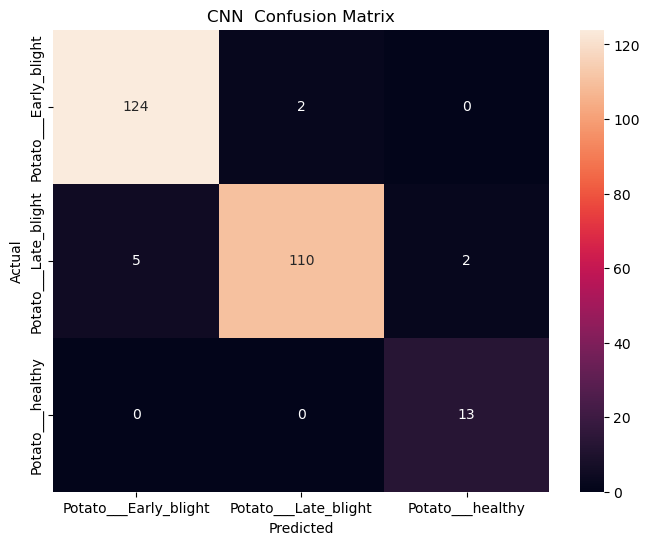

In [55]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN  Confusion Matrix")
plt.show()

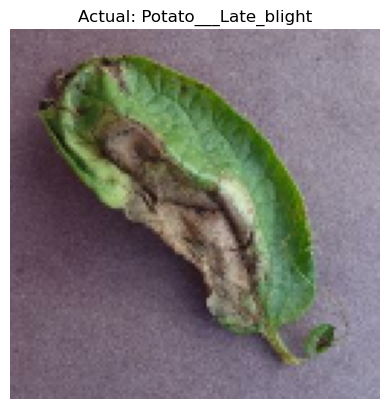

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
Predicted: Potato___Late_blight
Confidence: 99.98 %

VLM Explanation:
 The  leaf shows   signs  of  Late  Blight ,  serious  disease  that  requires  immediate  attention . 


In [36]:

for images, labels in test_ds.take(1):
    image = images[0]
    
    label = labels[0]

    # Show image
    
    plt.imshow(image.numpy() )
    plt.title("Actual: " + class_names[label] )
    plt.axis("off" )
    plt.show()

    # Prepare image 
    
    img_array = np.expand_dims(image,  axis=0  )

    # Predict
    
    predictions = model_CNN.predict(img_array)
    
    predicted_class = class_names[np.argmax( predictions [0] ) ]
    
    confidence = round(100 * np.max(predictions[0]), 2)

    print("Predicted:", predicted_class)
    
    print("Confidence:", confidence, "%")
if predicted_class == "Potato___healthy":
    explanation = " The  potato  leaf  is  healthy  and  shows no signs of disease. No treatment is required . "

elif predicted_class == "Potato___Early_blight":
    explanation = "The leaf shows signs of    Early  Blight ,  which  appears  as  dark  spot ,  Proper treatment is recommended . " 

elif predicted_class == "Potato___Late_blight":
    explanation = " The  leaf shows   signs  of  Late  Blight ,  serious  disease  that  requires  immediate  attention . "

print("\nVLM Explanation:")
print(explanation)

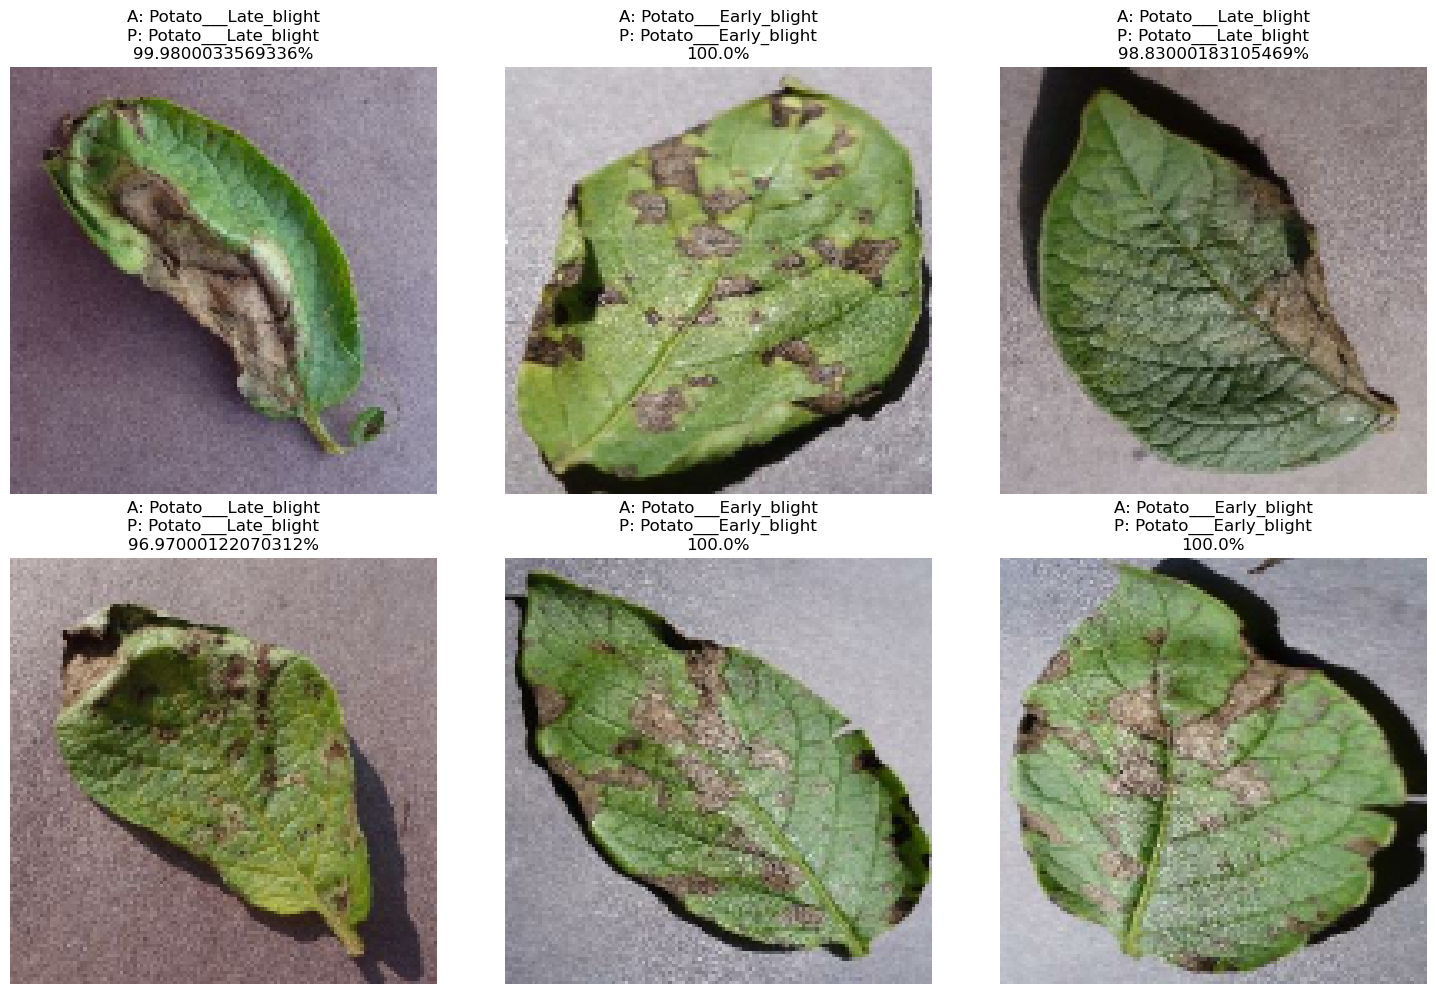

In [37]:

plt.figure(figsize=(15, 10))

for images, labels in test_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)

        image = images[i]
        label = labels[i]

        # Prediction
        img_array = np.expand_dims(image, axis=0)
        predictions = model_CNN.predict(img_array, verbose=0)

        predicted_class = class_names[np.argmax(predictions[0])]
        confidence = round(100 * np.max(predictions[0]), 2)

        # VLM Explanation
        if predicted_class == "Potato___healthy":
            explanation = "Healthy"
        elif predicted_class == "Potato___Early_blight":
            explanation = "Early Blight"
        else:
            explanation = "Late Blight"

        # Show image
        plt.imshow(image.numpy())
        plt.title(f"A: {class_names[label]}\nP: {predicted_class}\n{confidence}%")
        plt.axis("off")

plt.tight_layout()
plt.show()

#  Built MobileNetV2  model  

In [38]:
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,   # remove original classifier
    weights='imagenet')

In [39]:
base_model.trainable = False

In [40]:
model_mobilenetV2= models.Sequential([

    # preprocessing
    layers.Resizing(128, 128),
    data_augmentation,

    # Pretrained feature extractor
    base_model,

    # Convert feature maps → vector
    layers.GlobalAveragePooling2D(),

    # Custom classifier
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')]) # 3 classes

In [41]:
model_mobilenetV2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [43]:
history = model_mobilenetV2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 339ms/step - accuracy: 0.8732 - loss: 0.3099 - val_accuracy: 0.9479 - val_loss: 0.1531
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 244ms/step - accuracy: 0.9349 - loss: 0.1705 - val_accuracy: 0.9375 - val_loss: 0.1467
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - accuracy: 0.9360 - loss: 0.1527 - val_accuracy: 0.9635 - val_loss: 0.1256
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.9407 - loss: 0.1324 - val_accuracy: 0.9635 - val_loss: 0.1216
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 244ms/step - accuracy: 0.9595 - loss: 0.1079 - val_accuracy: 0.9583 - val_loss: 0.1451
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.9554 - loss: 0.1205 - val_accuracy: 0.9427 - val_loss: 0.1412
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9624 - loss: 0.1008 - val_accuracy: 0.9583 - val_loss: 0.0836
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.9636 - loss: 0.1074 - val_accuracy

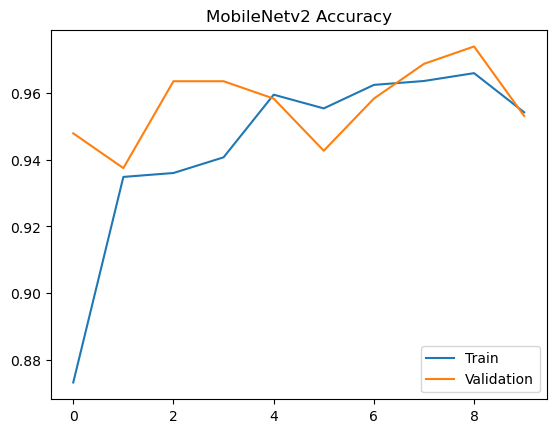

In [44]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'  ])
plt.title("MobileNetv2 Accuracy")
plt.show()

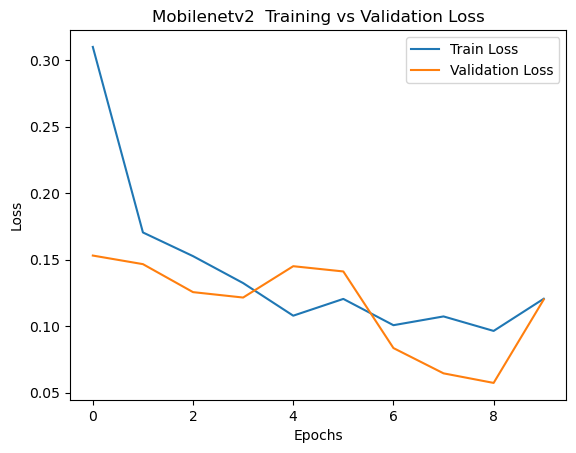

In [45]:
# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Mobilenetv2  Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [46]:
model_mobilenetV2.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - accuracy: 0.9531 - loss: 0.1079


[0.10789066553115845, 0.953125]

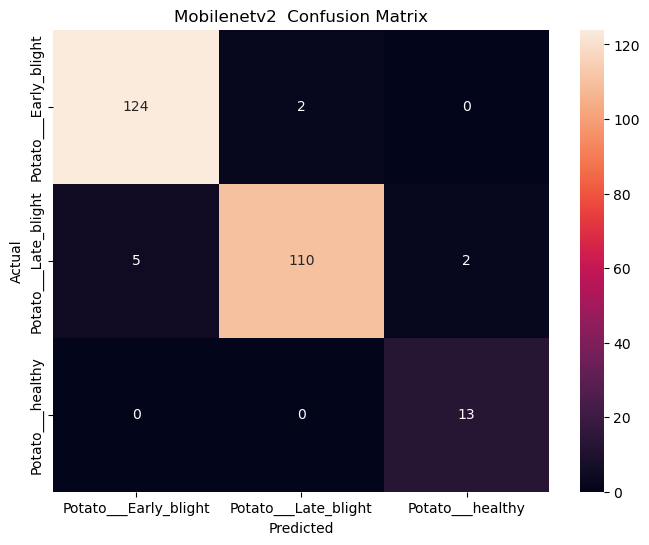

In [47]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Mobilenetv2  Confusion Matrix")
plt.show()

In [48]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       126
           1       0.98      0.94      0.96       117
           2       0.87      1.00      0.93        13

    accuracy                           0.96       256
   macro avg       0.94      0.97      0.95       256
weighted avg       0.97      0.96      0.96       256



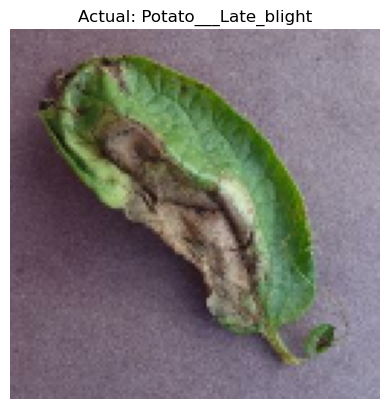

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted: Potato___Late_blight
Confidence: 100.0 %

VLM Explanation:
 The  leaf shows   signs  of  Late  Blight ,  serious  disease  that  requires  immediate  attention . 


In [49]:
for images, labels in test_ds.take(1):
    image = images[0]
    
    label = labels[0]

    # Show image
    
    plt.imshow(image.numpy() )
    plt.title("Actual: " + class_names[label] )
    plt.axis("off" )
    plt.show()

    # Prepare image 
    
    img_array = np.expand_dims(image,  axis=0  )

    # Predict
    
    predictions = model_mobilenetV2.predict(img_array)
    
    predicted_class = class_names[np.argmax( predictions [0] ) ]
    
    confidence = round(100 * np.max(predictions[0]), 2)

    print("Predicted:", predicted_class)
    
    print("Confidence:", confidence, "%")
if predicted_class == "Potato___healthy":
    explanation = " The  potato  leaf  is  healthy  and  shows no signs of disease. No treatment is required . "

elif predicted_class == "Potato___Early_blight":
    explanation = "The leaf shows signs of    Early  Blight ,  which  appears  as  dark  spot ,  Proper treatment is recommended . " 

elif predicted_class == "Potato___Late_blight":
    explanation = " The  leaf shows   signs  of  Late  Blight ,  serious  disease  that  requires  immediate  attention . "

print("\nVLM Explanation:")
print(explanation)

#  As per  above  observation  my  MobilenetV2  perform  vry  well  as compare  to  cnn  ,  now  let's  try  real  world  image  which  is  not  part  of  my  data 

# creating  a  class  function  to  run  CNN  and  MobileNetV2   for  real  world  image  prediction  

In [50]:
class PlantPredictor:
    def __init__(self, model_cnn, model_mobilenet, class_names):
        
        self.model_cnn =  model_cnn
        self.model_mobilenet =   model_mobilenet
        self.class_names =  class_names

    def preprocess(self, img_path):
        img = image.load_img(img_path, target_size=(128,128))
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        return img, img_array

    def predict(self, img_path):
        # Preprocessing 
        img, img_array = self.preprocess(img_path)

        # Show real image ONCE
        plt.imshow(img)
        plt.title("Input Image")
        plt.axis("off")
        plt.show()

        # CNN Prediction
        pred_cnn = self.model_cnn.predict(img_array)
        cnn_class = self.class_names[np.argmax(pred_cnn)]
        cnn_conf = round(np.max(pred_cnn) * 100, 2)

        # MobileNet Prediction
        pred_mob = self.model_mobilenet.predict(img_array)
        mob_class = self.class_names[np.argmax(pred_mob)]
        mob_conf = round(np.max(pred_mob) * 100, 2)

        # Print results
        print("===== PREDICTIONS =====")
        print(f"CNN Prediction: {cnn_class} ({cnn_conf}%)")
        print(f"MobileNetV2 Prediction: {mob_class} ({mob_conf}%)")

#  let's try  real  world image  healty  potato  by  CNN  and  MobilenetV2

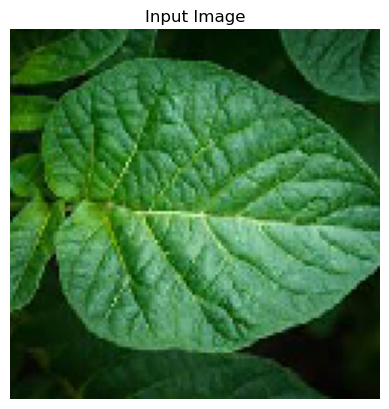

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
===== PREDICTIONS =====
CNN Prediction: Potato___Early_blight (100.0%)
MobileNetV2 Prediction: Potato___healthy (53.459999084472656%)


In [52]:
from tensorflow.keras.preprocessing import image
class_names = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

predictor = PlantPredictor(model_CNN, model_mobilenetV2, class_names)

img_path = r"C:\Users\Dev\Downloads\healthy  potato  1.jpg"
predictor.predict(img_path)

#  let's try  real  world image  late blight   potato   by  CNN  and  MobilenetV2

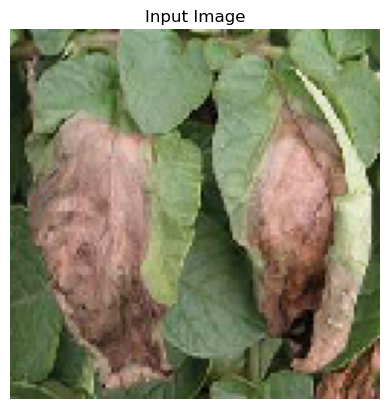

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
===== PREDICTIONS =====
CNN Prediction: Potato___Early_blight (99.9000015258789%)
MobileNetV2 Prediction: Potato___Late_blight (91.55000305175781%)


In [53]:
class_names = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

predictor = PlantPredictor(model_CNN, model_mobilenetV2, class_names)

img_path = r"C:\Users\Dev\Downloads\late blight potato  1.jpg"
predictor.predict(img_path)

#  let's try  real  world image  early  blight  potato  by  CNN  and  MobilenetV2

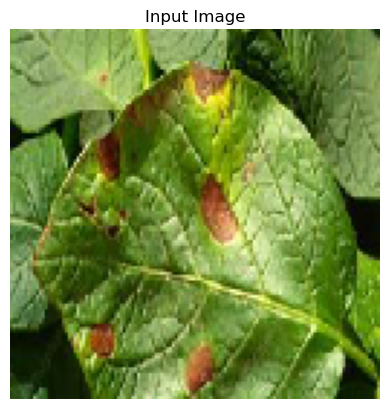

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
===== PREDICTIONS =====
CNN Prediction: Potato___Early_blight (100.0%)
MobileNetV2 Prediction: Potato___Early_blight (97.04000091552734%)


In [54]:
class_names = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

predictor = PlantPredictor(model_CNN, model_mobilenetV2, class_names)

img_path = r"C:\Users\Dev\Downloads\Early_blight_potato.jpg"
predictor.predict(img_path)

# Thank  you